#### This document is for analysis on FACT-E emotional well being (EWB).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import re

# Preliminary

In [2]:
# Read the CSV file - linked file 
file_path = "Merged_TSQIC_REDCap_ACCESS.xlsx" 
df = pd.read_excel(file_path)
df

,id,operation_date,redcap_event_name,dob,qol_date,age_diagnosis,gender,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,...,ge1,ge2,ge3,ge4,ge5,ge6,readmission_30d,postop_comp,los,DischargeDate
0,1,NaT,baseline_arm_1,1949-08-04,NaT,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27
1,1,2011-08-26,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26
2,1,2010-02-20,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08
3,1,2009-05-27,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2009-05-27
4,1,2009-02-25,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10094,1766,NaT,baseline_arm_1,NaT,NaT,62.845917,NaN,1b,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10095,1766,2025-02-26,surgery_arm_1,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10096,1767,NaT,baseline_arm_1,1971-12-18,NaT,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10097,1767,NaT,baseline_arm_1,NaT,2025-03-03,NaN,NaN,NaN,NaN,NaN,...,0.0,2.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN,NaT


In [3]:
# Get unique combinations of id and los, then calculate statistics
unique_patient_los = df[['id', 'los']].drop_duplicates()
average_los = unique_patient_los['los'].mean()
patient_count = unique_patient_los['id'].nunique()
sd_los = unique_patient_los['los'].std()
se_los = unique_patient_los['los'].std() / (len(unique_patient_los) ** 0.5)

print(f"General patient population count: {patient_count}")
print(f"Average LOS for general patient population: {average_los}")
print(f"Standard deviation: {sd_los}")
print(f"Standard error: {se_los}")

General patient population count: 1752
Average LOS for general patient population: 13.35904255319149
Standard deviation: 15.655942246495414
Standard error: 0.27437024588326664


In [4]:
# Extract columns with "GE1" to "GE6" with the first and second columns (patient id, duration)
# columns_to_extract = ["id", "redcap_event_name", "postop_comp", "los", "readmission_30d"] + [f"ge{i}" for i in range(1, 7)]
df_extracted = df.copy()#= df[columns_to_extract]

# Display the extracted data
print(df_extracted)

         id operation_date redcap_event_name        dob   qol_date  \
0         1            NaT    baseline_arm_1 1949-08-04        NaT   
1         1     2011-08-26               NaN        NaT        NaT   
2         1     2010-02-20               NaN        NaT        NaT   
3         1     2009-05-27               NaN        NaT        NaT   
4         1     2009-02-25               NaN        NaT        NaT   
...     ...            ...               ...        ...        ...   
10094  1766            NaT    baseline_arm_1        NaT        NaT   
10095  1766     2025-02-26     surgery_arm_1        NaT        NaT   
10096  1767            NaT    baseline_arm_1 1971-12-18        NaT   
10097  1767            NaT    baseline_arm_1        NaT 2025-03-03   
10098  1768            NaT    baseline_arm_1 1944-12-03        NaT   

       age_diagnosis  gender overall_primary_tumour overall_regional_ln  \
0                NaN     1.0                    NaN                 NaN   
1        

In [5]:
# Define GE score columns
ge_cols = ["ge1", "ge2", "ge3", "ge4", "ge5", "ge6"]

# Remove rows where all GE scores are NaN
df_filtered = df.dropna(subset=ge_cols, how="all")

# Group by 'id' and get unique redcap_event_name values per id
ids_with_both = df_filtered.groupby("id")["redcap_event_name"].unique()

# Filter for IDs that contain both 'baseline_arm_1' and 'preoperative_arm_1'
ids_with_both = ids_with_both[ids_with_both.apply(lambda x: {"baseline_arm_1", "preoperative_arm_1"}.issubset(set(x)))]

# Count the number of unique patients that satisfy the condition
num_ids_with_both = len(ids_with_both)

print(f"Number of IDs with both Baseline and Preoperative (after removing NaN GE scores): {num_ids_with_both}")

Number of IDs with both Baseline and Preoperative (after removing NaN GE scores): 283


In [6]:
# Count the number of rows for each patient (id)
patient_row_counts = df["id"].value_counts()

# Display the result
print(patient_row_counts)

id
209     66
629     52
276     49
169     48
263     48
        ..
1534     1
1533     1
1501     1
1498     1
1768     1
Name: count, Length: 1752, dtype: int64


In [7]:
# Get unique categories in "redcap_event_name"
unique_categories = df["redcap_event_name"].unique()

# Display the result
print(unique_categories)

['baseline_arm_1' nan 'surgery_arm_1' 'preoperative_arm_1']


In [8]:
# Create new columns for emotional well-being sub-domain scores
def process_ge_score(x, reverse=True):
    if isinstance(x, list):
        return [4 - val if reverse else val for val in x]
    return 4 - x if reverse else x

df["ge1_score"] = df["ge1"].apply(lambda x: process_ge_score(x, reverse=True))
df["ge2_score"] = df["ge2"].apply(lambda x: process_ge_score(x, reverse=False)) 
df["ge3_score"] = df["ge3"].apply(lambda x: process_ge_score(x, reverse=True))
df["ge4_score"] = df["ge4"].apply(lambda x: process_ge_score(x, reverse=True))
df["ge5_score"] = df["ge5"].apply(lambda x: process_ge_score(x, reverse=True))
df["ge6_score"] = df["ge6"].apply(lambda x: process_ge_score(x, reverse=True))

# Filter data for baseline_arm_1 and preoperative_arm_1
baseline_df = df[df["redcap_event_name"] == "baseline_arm_1"]
preoperative_df = df[df["redcap_event_name"] == "preoperative_arm_1"]

# distribution of FACT-E Emotional Well-Being sub-domain at 1) baseline and 2) pre-operative.

In [9]:
# Calculate distribution (value counts, ignoring missing values)
def count_values(series):
    value_counts = {}
    for value in series.dropna():
        if isinstance(value, list):
            # Count each value in the list
            for v in value:
                value_counts[v] = value_counts.get(v, 0) + 1
        else:
            # Count single values
            value_counts[value] = value_counts.get(value, 0) + 1
    return pd.Series(value_counts)

# Calculate distributions using the custom counting function
baseline_distribution = baseline_df[["ge1_score", "ge2_score", "ge3_score", 
                                "ge4_score", "ge5_score", "ge6_score"]].apply(count_values)
preoperative_distribution = preoperative_df[["ge1_score", "ge2_score", "ge3_score",
                                        "ge4_score", "ge5_score", "ge6_score"]].apply(count_values)

# Display results - Table
print("Baseline Distribution:")
print(baseline_distribution)

print("\nPreoperative Distribution:") 
print(preoperative_distribution)

Baseline Distribution:
     ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  ge6_score
0.0         62        104         37        137        105        188
1.0        118        135         44        154        104        180
2.0        242        320        106        237        169        259
3.0        296        299        172        267        257        244
4.0        334        161        622        243        400        169

Preoperative Distribution:
     ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  ge6_score
0.0          8         35         14         23         17         38
1.0         23         36         17         45         36         57
2.0         84        120         38         98         53         99
3.0        125        134         63        135        125        131
4.0        189        102        292        128        196        102


In [10]:
# Melt the data for visualization
baseline_melted = baseline_df.melt(id_vars=["id"], value_vars=["ge1_score", "ge2_score", "ge3_score", "ge4_score", "ge5_score", "ge6_score"], var_name="Score Type", value_name="Score")
preoperative_melted = preoperative_df.melt(id_vars=["id"], value_vars=["ge1_score", "ge2_score", "ge3_score", "ge4_score", "ge5_score", "ge6_score"], var_name="Score Type", value_name="Score")

In [11]:
baseline_melted["Timepoint"] = "Baseline"
preoperative_melted["Timepoint"] = "Preoperative"

combined_df = pd.concat([baseline_melted, preoperative_melted])
combined_df

,id,Score Type,Score,Timepoint
0,1,ge1_score,NaN,Baseline
1,1,ge1_score,NaN,Baseline
2,2,ge1_score,3.0,Baseline
3,2,ge1_score,NaN,Baseline
4,2,ge1_score,NaN,Baseline
...,...,...,...,...
12091,1752,ge6_score,NaN,Preoperative
12092,1752,ge6_score,3.0,Preoperative
12093,1762,ge6_score,NaN,Preoperative
12094,1764,ge6_score,NaN,Preoperative


In [12]:
# Ensure no duplicate issues
combined_df = combined_df.dropna()

combined_df

,id,Score Type,Score,Timepoint
2,2,ge1_score,3.0,Baseline
7,3,ge1_score,2.0,Baseline
9,4,ge1_score,4.0,Baseline
18,7,ge1_score,1.0,Baseline
19,8,ge1_score,4.0,Baseline
...,...,...,...,...
12078,1738,ge6_score,4.0,Preoperative
12080,1739,ge6_score,3.0,Preoperative
12082,1740,ge6_score,2.0,Preoperative
12085,1744,ge6_score,2.0,Preoperative


In [13]:
# Function to explode list values into separate rows
def process_score(score):
    if isinstance(score, list):
        return score
    return [score]

# Convert Score column to lists and explode
combined_df['Score'] = combined_df['Score'].apply(process_score)
combined_df = combined_df.explode('Score')

# Display example rows
combined_df

/tmp/ipykernel_3604838/65139597.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df['Score'] = combined_df['Score'].apply(process_score)


,id,Score Type,Score,Timepoint
2,2,ge1_score,3.0,Baseline
7,3,ge1_score,2.0,Baseline
9,4,ge1_score,4.0,Baseline
18,7,ge1_score,1.0,Baseline
19,8,ge1_score,4.0,Baseline
...,...,...,...,...
12078,1738,ge6_score,4.0,Preoperative
12080,1739,ge6_score,3.0,Preoperative
12082,1740,ge6_score,2.0,Preoperative
12085,1744,ge6_score,2.0,Preoperative


In [14]:
score_distribution_by_timepoint = combined_df.groupby(["Score", "Timepoint"]).size().unstack()
print(score_distribution_by_timepoint)

Timepoint  Baseline  Preoperative
Score                            
0.0             633           135
1.0             735           214
2.0            1333           492
3.0            1535           713
4.0            1929          1009


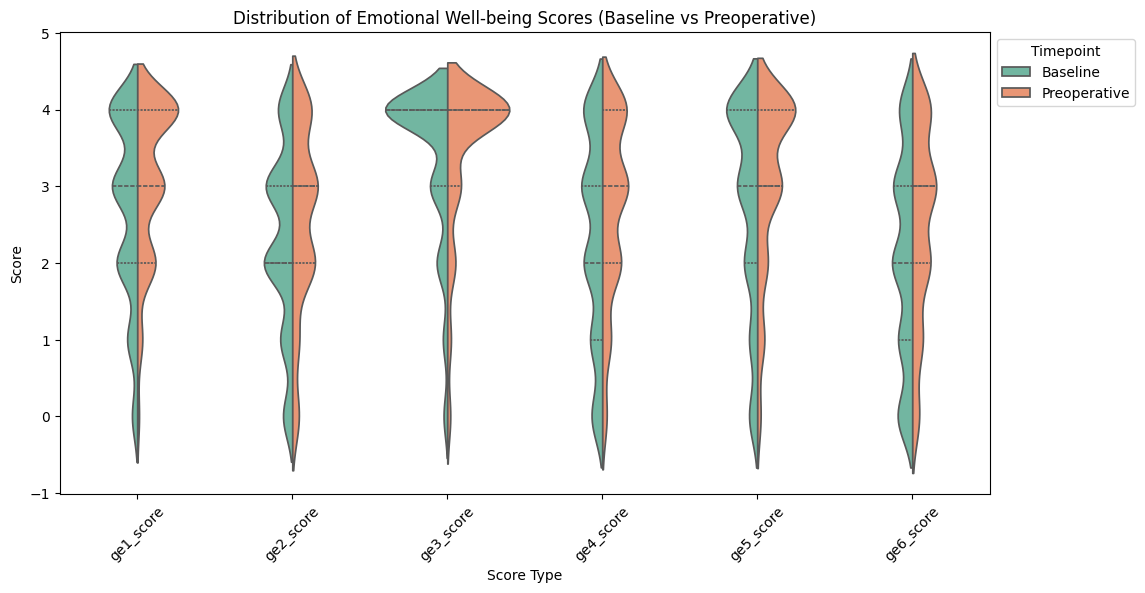

In [15]:
# === Violin Plot ===
plt.figure(figsize=(12, 6))
sns.violinplot(x="Score Type", y="Score", hue="Timepoint", data=combined_df, split=True, inner="quartile", palette="Set2")
plt.title("Distribution of Emotional Well-being Scores (Baseline vs Preoperative)")
plt.xticks(rotation=45)
plt.legend(title="Timepoint", loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

# frequency of those that have both baseline and pre-operative FACT-E

In [16]:
# Identify patients who have both baseline and preoperative
patients_with_both = combined_df.groupby("id")["Timepoint"].unique()
patients_with_both = patients_with_both[patients_with_both.apply(lambda x: {"Baseline", "Preoperative"}.issubset(set(x)))].index

# Keep only rows where id is in the list of patients_with_both
filtered_df = combined_df[combined_df["id"].isin(patients_with_both)]

print(filtered_df)

score_distribution_by_timepoint2 = filtered_df.groupby(["Score", "Timepoint"]).size().unstack()
print(score_distribution_by_timepoint2)

         id Score Type Score     Timepoint
138      55  ge1_score   2.0      Baseline
194      78  ge1_score   4.0      Baseline
281     125  ge1_score   3.0      Baseline
286     127  ge1_score   1.0      Baseline
290     128  ge1_score   3.0      Baseline
...     ...        ...   ...           ...
12066  1729  ge6_score   4.0  Preoperative
12074  1736  ge6_score   4.0  Preoperative
12076  1737  ge6_score   0.0  Preoperative
12080  1739  ge6_score   3.0  Preoperative
12085  1744  ge6_score   2.0  Preoperative

[3852 rows x 4 columns]
Timepoint  Baseline  Preoperative
Score                            
0.0             188            92
1.0             261           155
2.0             446           359
3.0             485           529
4.0             599           738


In [17]:
# Count the number of unique patients
num_patients_with_both = len(patients_with_both)

print(f"Number of patients with both Baseline and Preoperative: {num_patients_with_both}")

Number of patients with both Baseline and Preoperative: 283


In [18]:
ge_scores = ["ge1_score", "ge2_score", "ge3_score", "ge4_score", "ge5_score", "ge6_score"]

# Separate data by Timepoint
baseline_df_filtered = filtered_df[filtered_df["Timepoint"] == "Baseline"]
preoperative_df_filtered = filtered_df[filtered_df["Timepoint"] == "Preoperative"]

# Pivot table: Count occurrences of each Score for each Score Type
baseline_table = baseline_df_filtered.pivot_table(index="Score", columns="Score Type", aggfunc="size", fill_value=0)
preoperative_table = preoperative_df_filtered.pivot_table(index="Score", columns="Score Type", aggfunc="size", fill_value=0)

# Display the tables
print("Baseline Score Distribution Table:")
print(baseline_table)

print("\nPreoperative Score Distribution Table:")
print(preoperative_table)


Baseline Score Distribution Table:
Score Type  ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  ge6_score
Score                                                                       
0.0                16         36         10         35         32         59
1.0                37         45         17         61         34         67
2.0                85        116         31         75         58         81
3.0                97         74         54         91         92         77
4.0                99         59        207         70        115         49

Preoperative Score Distribution Table:
Score Type  ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  ge6_score
Score                                                                       
0.0                 6         27         10         15         11         23
1.0                15         27         13         32         24         44
2.0                60         88         29         68         41         73
3

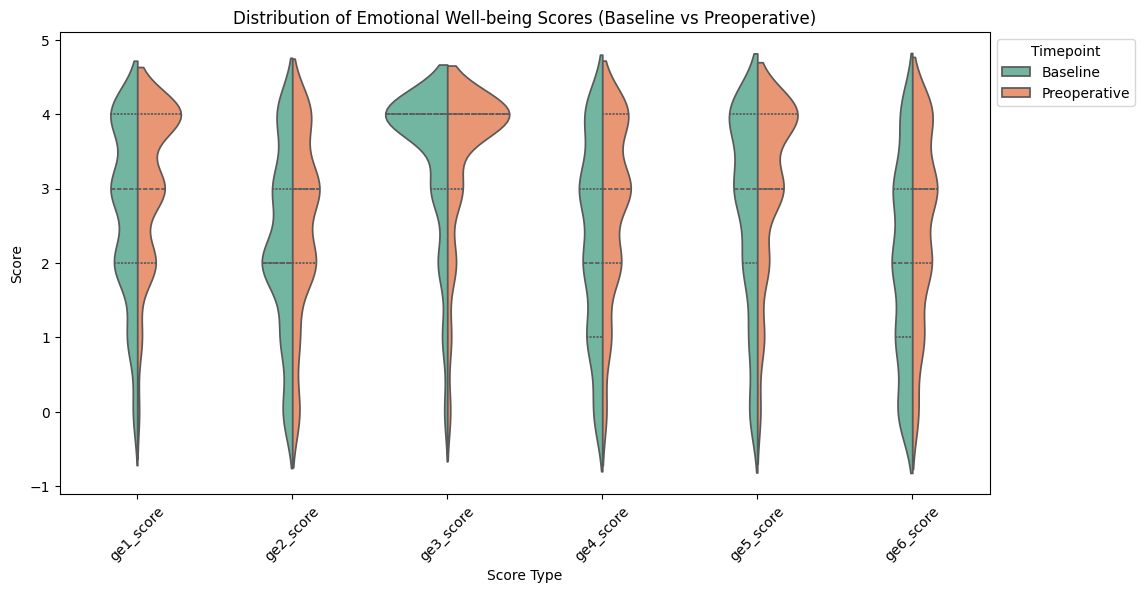

In [19]:
# === Violin Plot ===
plt.figure(figsize=(12, 6))
sns.violinplot(x="Score Type", y="Score", hue="Timepoint", data=filtered_df, split=True, inner="quartile", palette="Set2")
plt.title("Distribution of Emotional Well-being Scores (Baseline vs Preoperative)")
plt.xticks(rotation=45)
plt.legend(title="Timepoint", loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

# calculate how many improve, stay the same, or decrease from baseline --> preop

In [20]:
filtered_df

,id,Score Type,Score,Timepoint
138,55,ge1_score,2.0,Baseline
194,78,ge1_score,4.0,Baseline
281,125,ge1_score,3.0,Baseline
286,127,ge1_score,1.0,Baseline
290,128,ge1_score,3.0,Baseline
...,...,...,...,...
12066,1729,ge6_score,4.0,Preoperative
12074,1736,ge6_score,4.0,Preoperative
12076,1737,ge6_score,0.0,Preoperative
12080,1739,ge6_score,3.0,Preoperative


In [21]:
# Average scores for duplicated (id, Score Type, Timepoint) entries
filtered_df_dup_avged = filtered_df.groupby(["id", "Score Type", "Timepoint"], as_index=False)["Score"].mean()
filtered_df_dup_avged

,id,Score Type,Timepoint,Score
0,55,ge1_score,Baseline,2.0
1,55,ge1_score,Preoperative,2.0
2,55,ge2_score,Baseline,2.0
3,55,ge2_score,Preoperative,2.0
4,55,ge3_score,Baseline,3.0
...,...,...,...,...
3361,1744,ge4_score,Preoperative,2.0
3362,1744,ge5_score,Baseline,4.0
3363,1744,ge5_score,Preoperative,4.0
3364,1744,ge6_score,Baseline,2.0


In [22]:
# Count expected number of rows per patient (should be 12 per patient)
expected_rows_per_patient = 12

# Count actual rows per patient
patient_counts = filtered_df_dup_avged.groupby("id").size()
patient_counts
# Identify patients who do NOT have exactly 12 rows
patients_missing_rows = patient_counts[patient_counts != expected_rows_per_patient]

# Display IDs and their actual row count
print("Patients with missing rows and their row count:")
print(patients_missing_rows)

Patients with missing rows and their row count:
id
260     11
548     10
566     11
788     11
826     11
898     11
1003    11
1012    11
1043    11
1106    11
1126     9
1313    11
1409    10
1551    11
1560    11
1629    11
1710     9
1715    11
1723     6
dtype: int64


In [23]:
# Pivot to make Score Types as columns and fill missing values with 0
pivot_df = filtered_df_dup_avged.pivot_table(index=["id", "Timepoint"], 
                                columns="Score Type", 
                                values="Score", 
                                fill_value=0)

# Sum across all Score Types for each (id, Timepoint)
pivot_df["Total Score"] = pivot_df.sum(axis=1)

# Reset index to bring back "id" and "Timepoint" as columns
pivot_df = pivot_df.reset_index()
print(pivot_df)



# Count the number of non-missing values for each row (before replacing NaNs with 0)
num_answered = filtered_df_dup_avged.pivot_table(index=["id", "Timepoint"], 
                                    columns="Score Type", 
                                    values="Score", 
                                    aggfunc=lambda x: x.notna().sum())
num_answered

/tmp/ipykernel_3604838/3399530565.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pivot_df = filtered_df_dup_avged.pivot_table(index=["id", "Timepoint"],


Score Type    id     Timepoint  ge1_score  ge2_score  ge3_score  ge4_score  \
0             55      Baseline        2.0        2.0        3.0        1.0   
1             55  Preoperative        2.0        2.0        3.0        4.0   
2             78      Baseline        4.0        2.0        4.0        2.0   
3             78  Preoperative        4.0        2.0        4.0        3.0   
4            125      Baseline        3.0        3.0        4.0        4.0   
..           ...           ...        ...        ...        ...        ...   
561         1737  Preoperative        3.0        1.0        1.0        2.0   
562         1739      Baseline        1.0        2.0        4.0        2.0   
563         1739  Preoperative        4.0        3.0        4.0        3.0   
564         1744      Baseline        3.0        4.0        4.0        2.0   
565         1744  Preoperative        4.0        4.0        4.0        2.0   

Score Type  ge5_score  ge6_score  Total Score  
0              

Score Type         ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  \
id   Timepoint                                                             
55   Baseline            1.0        1.0        1.0        1.0        1.0   
     Preoperative        1.0        1.0        1.0        1.0        1.0   
78   Baseline            1.0        1.0        1.0        1.0        1.0   
     Preoperative        1.0        1.0        1.0        1.0        1.0   
125  Baseline            1.0        1.0        1.0        1.0        1.0   
...                      ...        ...        ...        ...        ...   
1737 Preoperative        1.0        1.0        1.0        1.0        1.0   
1739 Baseline            1.0        1.0        1.0        1.0        1.0   
     Preoperative        1.0        1.0        1.0        1.0        1.0   
1744 Baseline            1.0        1.0        1.0        1.0        1.0   
     Preoperative        1.0        1.0        1.0        1.0        1.0   

Score Type         ge6_score  
id   Timepoint                
55   Baseline            1.0  
     Preoperative        1.0  
78   Baseline            1.0  
     Preoperative        1.0  
125  Baseline            1.0  
...                      ...  
1737 Preoperative        1.0  
1739 Baseline            1.0  
     Preoperative        1.0  
1744 Baseline            1.0  
     Preoperative        1.0  

[566 rows x 6 columns]

In [24]:
#show the table where it is missing
num_answered[num_answered.sum(axis=1) != 6]

,Score Type,ge1_score,ge2_score,ge3_score,ge4_score,ge5_score,ge6_score
id,Timepoint,,,,,,
260,Baseline,1.0,1.0,NaN,1.0,1.0,1.0
548,Baseline,1.0,1.0,NaN,1.0,NaN,1.0
566,Baseline,1.0,1.0,NaN,1.0,1.0,1.0
788,Preoperative,1.0,1.0,NaN,1.0,1.0,1.0
826,Preoperative,1.0,1.0,1.0,1.0,1.0,NaN
898,Baseline,1.0,1.0,NaN,1.0,1.0,1.0
1003,Baseline,1.0,1.0,1.0,NaN,1.0,1.0
1012,Baseline,1.0,1.0,1.0,NaN,1.0,1.0
1043,Baseline,1.0,1.0,NaN,1.0,1.0,1.0


In [25]:
# Ensure num_answered has the same index as pivot_df
num_answered_sum = num_answered.sum(axis=1).reindex(pivot_df.set_index(["id", "Timepoint"]).index)

# Compute the Adjusted Score safely
pivot_df["EWB subscale Score"] = (pivot_df["Total Score"] * 6) / num_answered_sum.values


# Display result
pivot_df

Score Type,id,Timepoint,ge1_score,ge2_score,ge3_score,ge4_score,ge5_score,ge6_score,Total Score,EWB subscale Score
0,55,Baseline,2.0,2.0,3.0,1.0,0.0,0.0,8.0,8.0
1,55,Preoperative,2.0,2.0,3.0,4.0,2.0,1.0,14.0,14.0
2,78,Baseline,4.0,2.0,4.0,2.0,4.0,1.0,17.0,17.0
3,78,Preoperative,4.0,2.0,4.0,3.0,4.0,3.0,20.0,20.0
4,125,Baseline,3.0,3.0,4.0,4.0,4.0,3.0,21.0,21.0
...,...,...,...,...,...,...,...,...,...,...
561,1737,Preoperative,3.0,1.0,1.0,2.0,0.0,0.0,7.0,7.0
562,1739,Baseline,1.0,2.0,4.0,2.0,2.0,2.0,13.0,13.0
563,1739,Preoperative,4.0,3.0,4.0,3.0,3.0,3.0,20.0,20.0
564,1744,Baseline,3.0,4.0,4.0,2.0,4.0,2.0,19.0,19.0


In [26]:
# Pivot to get baseline and preoperative scores side by side
score_comparison = pivot_df.pivot(index="id", columns="Timepoint", values="EWB subscale Score")

# Compute the change: preoperative - baseline
score_comparison["Change"] = score_comparison["Preoperative"] - score_comparison["Baseline"]

# Categorize improvement, no change, or decline
score_comparison["Trend"] = score_comparison["Change"].apply(
    lambda x: "Improved" if x > 0 else "Same" if x == 0 else "Decreased"
)

# Display result
print(score_comparison[["Baseline", "Preoperative", "Change", "Trend"]])

Timepoint  Baseline  Preoperative  Change      Trend
id                                                  
55              8.0          14.0     6.0   Improved
78             17.0          20.0     3.0   Improved
125            21.0          16.0    -5.0  Decreased
127             5.0          12.0     7.0   Improved
128            22.0          23.0     1.0   Improved
...             ...           ...     ...        ...
1729           18.0          24.0     6.0   Improved
1736           20.0          21.0     1.0   Improved
1737           21.0           7.0   -14.0  Decreased
1739           13.0          20.0     7.0   Improved
1744           19.0          20.0     1.0   Improved

[283 rows x 4 columns]


/tmp/ipykernel_3604838/3399833115.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trend_counts.index, y=trend_counts.values, palette=["green", "gray", "red"])


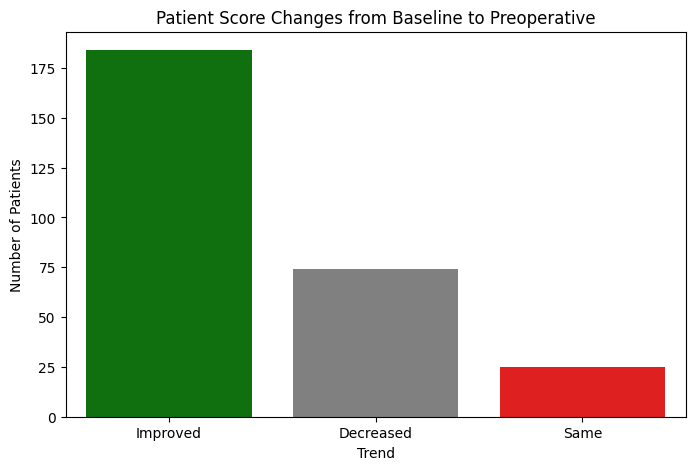

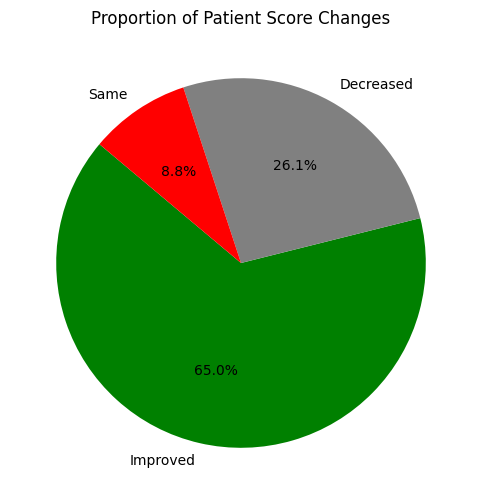

In [27]:
# Count the number of patients in each category
trend_counts = score_comparison["Trend"].value_counts()

# === 1. Bar Plot ===
plt.figure(figsize=(8, 5))
sns.barplot(x=trend_counts.index, y=trend_counts.values, palette=["green", "gray", "red"])
plt.title("Patient Score Changes from Baseline to Preoperative")
plt.xlabel("Trend")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

# === 2. Pie Chart ===
plt.figure(figsize=(6, 6))
plt.pie(trend_counts, labels=trend_counts.index, autopct="%1.1f%%", colors=["green", "gray", "red"], startangle=140)
plt.title("Proportion of Patient Score Changes")
plt.show()

# Categorize patients into: 1) improvers or 2) decliners / stay the same

In [28]:
score_comparison

Timepoint,Baseline,Preoperative,Change,Trend
id,,,,
55,8.0,14.0,6.0,Improved
78,17.0,20.0,3.0,Improved
125,21.0,16.0,-5.0,Decreased
127,5.0,12.0,7.0,Improved
128,22.0,23.0,1.0,Improved
...,...,...,...,...
1729,18.0,24.0,6.0,Improved
1736,20.0,21.0,1.0,Improved
1737,21.0,7.0,-14.0,Decreased


In [29]:
# Re-categorize into two groups
score_comparison["Trend Category"] = score_comparison["Change"].apply(lambda x: "Improved" if x > 0 else "Decreased/Same")

score_comparison

Timepoint,Baseline,Preoperative,Change,Trend,Trend Category
id,,,,,
55,8.0,14.0,6.0,Improved,Improved
78,17.0,20.0,3.0,Improved,Improved
125,21.0,16.0,-5.0,Decreased,Decreased/Same
127,5.0,12.0,7.0,Improved,Improved
128,22.0,23.0,1.0,Improved,Improved
...,...,...,...,...,...
1729,18.0,24.0,6.0,Improved,Improved
1736,20.0,21.0,1.0,Improved,Improved
1737,21.0,7.0,-14.0,Decreased,Decreased/Same


In [30]:
trend_counts = score_comparison["Trend Category"].value_counts()
trend_counts

Trend Category
Improved          184
Decreased/Same     99
Name: count, dtype: int64

/tmp/ipykernel_3604838/3720356275.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trend_counts.index, y=trend_counts.values, palette=["green", "red"])


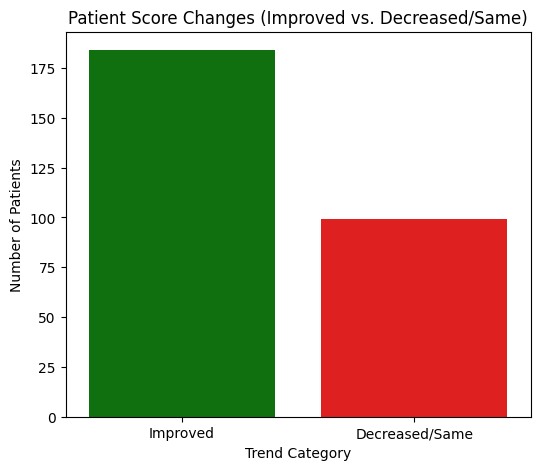

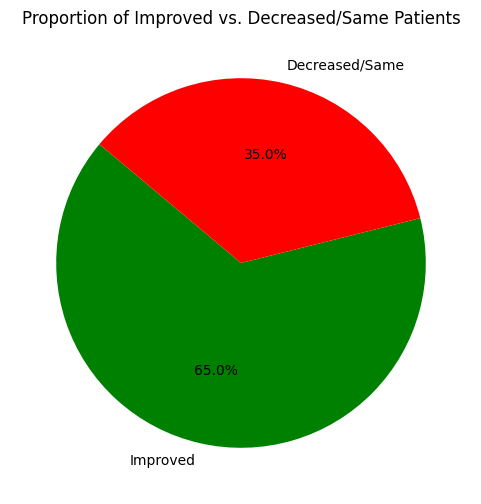

In [31]:
# === 1. Bar Plot ===
plt.figure(figsize=(6, 5))
sns.barplot(x=trend_counts.index, y=trend_counts.values, palette=["green", "red"])
plt.title("Patient Score Changes (Improved vs. Decreased/Same)")
plt.xlabel("Trend Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

# === 2. Pie Chart ===
plt.figure(figsize=(6, 6))
plt.pie(trend_counts, labels=trend_counts.index, autopct="%1.1f%%", colors=["green", "red"], startangle=140)
plt.title("Proportion of Improved vs. Decreased/Same Patients")
plt.show()

# When 50% of items threshold applied

In [32]:

# Step 1: Find eligible IDs (unchanged: requires both baseline_arm_1 and preoperative_arm_1)
def find_eligible_ids(df):
    id_events = df.groupby('id')['redcap_event_name'].apply(set)
    eligible_ids = []
    for id_val, events in id_events.items():
        has_baseline = "baseline_arm_1" in events
        has_preop = "preoperative_arm_1" in events
        if has_baseline and has_preop:  # Must have both
            eligible_ids.append(id_val)
    return eligible_ids

# Step 2: Filter dataset (unchanged)
def filter_eligible_data(df, eligible_ids):
    return df[df['id'].isin(eligible_ids)].copy()

# Step 3: Calculate EWB subscale score only (unchanged)
def calculate_subscale_score(df, cols, reverse_items=None, subscale_name=""):
    """Calculate subscale scores according to FACT scoring guidelines, only if >=50% items are answered"""
    for col in cols:
        df[f"{col}_score"] = pd.to_numeric(df[col], errors='coerce')
        if reverse_items and col in reverse_items:
            df[f"{col}_score"] = 4 - df[f"{col}_score"]
    
    total_items = len(cols)
    min_items_required = total_items / 2  # 50% threshold
    
    score_cols = [f"{col}_score" for col in cols]
    num_answered_items = df[score_cols].notna().sum(axis=1)
    
    df[f"{subscale_name}_subscale_score"] = np.where(
        num_answered_items >= min_items_required,
        (df[score_cols].sum(axis=1, skipna=True) * total_items) / 
        df[score_cols].notna().sum(axis=1),
        np.nan
    )
    return df

def calculate_all_scores(df):
    ewb_cols = [f"ge{i}" for i in range(1, 7)]
    ewb_reverse = [f"ge{i}" for i in range(1, 7) if i != 2]
    df = calculate_subscale_score(df, ewb_cols, ewb_reverse, "ewb")
    return df

# Step 4: Analyze improvement for EWB score only (updated to require calculatable scores)
def analyze_improvement(df):
    results = []
    unique_ids = df['id'].unique()
    
    score_types = ['ewb_subscale_score']  # Only EWB score
    
    for id_val in unique_ids:
        id_data = df[df['id'] == id_val]
        events = id_data['redcap_event_name'].unique()
        print(f"\nID {id_val} has events: {events}")
        
        event_scores = id_data.groupby('redcap_event_name')[score_types].mean().reset_index()
        
        baseline_score = event_scores[event_scores['redcap_event_name'] == 'baseline_arm_1']
        preop_score = event_scores[event_scores['redcap_event_name'] == 'preoperative_arm_1']
        
        # Skip if either baseline or preop data is missing
        if baseline_score.empty or preop_score.empty:
            continue
            
        baseline_values = baseline_score[score_types].iloc[0].to_dict()
        preop_values = preop_score[score_types].iloc[0].to_dict()
        
        # Skip if EWB score is not calculatable (NaN) for either time point
        if pd.isna(baseline_values['ewb_subscale_score']) or pd.isna(preop_values['ewb_subscale_score']):
            print(f"Skipping ID {id_val}: EWB score not calculatable (Baseline: {baseline_values['ewb_subscale_score']}, Preop: {preop_values['ewb_subscale_score']})")
            continue
        
        # Print scores
        print(f"Baseline score: [{', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items()])}]")
        print(f"Preop score: [{', '.join([f'{k}: {v:.1f}' for k, v in preop_values.items()])}]")
        
        # Calculate improvement (preop - baseline)
        result = {'id': id_val, 'baseline_type': 'baseline_arm_1'}
        for score_type in score_types:
            improvement = preop_values[score_type] - baseline_values[score_type]
            result.update({
                f'{score_type}_baseline': baseline_values[score_type],
                f'{score_type}_preop': preop_values[score_type],
                f'{score_type}_improvement': improvement,
                f'{score_type}_has_improved': improvement >= 5
            })
        
        results.append(result)
    
    return pd.DataFrame(results)

# Main function (unchanged)
def analyze_patient_outcomes(df):
    required_cols = ['id', 'redcap_event_name'] + [f"ge{i}" for i in range(1, 7)]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
    
    eligible_ids = find_eligible_ids(df)
    print(f"Found {len(eligible_ids)} eligible IDs")
    
    filtered_df = filter_eligible_data(df, eligible_ids)
    print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    filtered_df = calculate_all_scores(filtered_df)
    
    score_cols = [col for col in filtered_df.columns if col.endswith('_score')]
    print(f"Created score columns: {score_cols}")
    
    score_types = ['ewb_subscale_score']
    for score_type in score_types:
        non_nan_count = filtered_df[score_type].notna().sum()
        print(f"Non-NaN {score_type}: {non_nan_count} out of {len(filtered_df)}")
    
    results_df = analyze_improvement(filtered_df)
    
    if not results_df.empty:
        print(f"\nAnalysis complete for {len(results_df)} patients:")
        for score_type in score_types:
            valid_improvements = results_df[f'{score_type}_improvement'].notna().sum()
            if valid_improvements > 0:
                improved = results_df[f'{score_type}_has_improved'].sum()
                rate = (improved / valid_improvements) * 100
                print(f"Patients with {score_type} improvement (≥5 points): {improved} out of {valid_improvements} ({rate:.1f}%)")
            else:
                print(f"Patients with {score_type} improvement (≥5 points): 0 out of 0 (0.0%)")
    return filtered_df, results_df

# Example usage
filtered_df, results_df = analyze_patient_outcomes(df)

Found 1522 eligible IDs
Filtered dataframe shape: (9345, 33)
Created score columns: ['ge1_score', 'ge2_score', 'ge3_score', 'ge4_score', 'ge5_score', 'ge6_score', 'ewb_subscale_score']
Non-NaN ewb_subscale_score: 1393 out of 9345

ID 4 has events: ['surgery_arm_1' 'baseline_arm_1' 'preoperative_arm_1']
Skipping ID 4: EWB score not calculatable (Baseline: 23.0, Preop: nan)

ID 5 has events: ['surgery_arm_1' 'baseline_arm_1' 'preoperative_arm_1']
Skipping ID 5: EWB score not calculatable (Baseline: nan, Preop: nan)

ID 6 has events: ['baseline_arm_1' 'preoperative_arm_1' 'surgery_arm_1']
Skipping ID 6: EWB score not calculatable (Baseline: nan, Preop: nan)

ID 7 has events: ['surgery_arm_1' 'baseline_arm_1' 'preoperative_arm_1' nan]
Skipping ID 7: EWB score not calculatable (Baseline: 5.0, Preop: nan)

ID 8 has events: ['surgery_arm_1' 'baseline_arm_1' 'preoperative_arm_1']
Skipping ID 8: EWB score not calculatable (Baseline: 18.0, Preop: nan)

ID 9 has events: ['surgery_arm_1' 'preopera

In [33]:
results_df

,id,baseline_type,ewb_subscale_score_baseline,ewb_subscale_score_preop,ewb_subscale_score_improvement,ewb_subscale_score_has_improved
0,55,baseline_arm_1,8.0,14.0,6.0,True
1,78,baseline_arm_1,17.0,20.0,3.0,False
2,125,baseline_arm_1,21.0,16.0,-5.0,False
3,127,baseline_arm_1,5.0,12.0,7.0,True
4,128,baseline_arm_1,22.0,23.0,1.0,False
...,...,...,...,...,...,...
277,1729,baseline_arm_1,18.0,24.0,6.0,True
278,1736,baseline_arm_1,20.0,21.0,1.0,False
279,1737,baseline_arm_1,21.0,7.0,-14.0,False
280,1739,baseline_arm_1,13.0,20.0,7.0,True


In [34]:
missing_in_results_df = set(score_comparison.index) - set(results_df.id)
print("IDs in score_comparison.index but not in results_df.id:", missing_in_results_df)


IDs in score_comparison.index but not in results_df.id: {1723}


In [35]:
# Drop the specified columns
results_df = results_df.drop(columns=["baseline_type", "ewb_subscale_score_has_improved"])

# Rename the specified columns
results_df = results_df.rename(columns={
    "ewb_subscale_score_baseline": "Baseline",
    "ewb_subscale_score_preop": "Preoperative",
    "ewb_subscale_score_improvement": "Change"
})

results_df["Trend Category"] = results_df["Change"].apply(
    lambda x: "Improved" if pd.notna(x) and x > 0 else ("Decreased/Same" if pd.notna(x) else None)
)
results_df["Trend Category"].value_counts()

Trend Category
Improved          186
Decreased/Same     96
Name: count, dtype: int64

In [36]:
# Set 'id' column as the index
results_df = results_df.set_index("id")

# Rename the index and columns to match the second image
results_df.index.name = "id"
results_df.columns.name = "Timepoint"

results_df
score_comparison=results_df.copy()

# Aligning cohorts

In [140]:
# ── Build one aligned cohort (one row per patient, all variables available) ──

aligned_df = score_comparison.copy()

aligned_df = aligned_df.merge(df_extracted[["id", "age_diagnosis"]].drop_duplicates(), on="id", how="left").dropna(subset=["age_diagnosis"])
aligned_df = aligned_df.merge(df_extracted[["id", "gender"]].drop_duplicates(), on="id", how="left").dropna(subset=["gender"])

# Tumor stage
tumor_map = {"99": None, "0": 0, "00": 0, "1": 1, "1a": 1, "1b": 1, "2": 2, "3": 3, "4": 4, "4a": 4, "4b": 4, "5": None}
tumor_temp = df_extracted[["id", "overall_primary_tumour"]].drop_duplicates().copy()
tumor_temp["overall_primary_tumour"] = tumor_temp["overall_primary_tumour"].map(tumor_map)
aligned_df = aligned_df.merge(tumor_temp, on="id", how="left").dropna(subset=["overall_primary_tumour"])

# LN stage
ln_map = {"99": None, "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "pos": 1}
ln_temp = df_extracted[["id", "overall_regional_ln"]].drop_duplicates().copy()
ln_temp["overall_regional_ln"] = ln_temp["overall_regional_ln"].map(ln_map)
aligned_df = aligned_df.merge(ln_temp, on="id", how="left").dropna(subset=["overall_regional_ln"])

# Metastasis
m_temp = df_extracted[["id", "overall_distant_metastasis"]].drop_duplicates().copy()
m_temp["overall_distant_metastasis"] = m_temp["overall_distant_metastasis"].map({0: 0, 1: 1, 2: None})
aligned_df = aligned_df.merge(m_temp, on="id", how="left").dropna(subset=["overall_distant_metastasis"])

# Neoadjuvant treatments
for col in ["neotx___notx", "neotx___chemo", "neotx___rads", "neotx___chemorads", "neotx___immuno", "neotx___other"]:
    aligned_df = aligned_df.merge(df_extracted[["id", col]].drop_duplicates(), on="id", how="left").dropna(subset=[col])

# postop_comp: earliest discharge, prefer postop_comp=1, exclude readmission=1
postop_temp = df_extracted[["id", "DischargeDate", "postop_comp", "readmission_30d"]].dropna(subset=["postop_comp"])
postop_temp = postop_temp.sort_values(by=["id", "DischargeDate", "postop_comp"], ascending=[True, True, False])
postop_temp = postop_temp.drop_duplicates(subset=["id"], keep="first")
postop_temp = postop_temp[postop_temp["readmission_30d"] != 1][["id", "postop_comp"]]
aligned_df = aligned_df.merge(postop_temp, on="id", how="left").dropna(subset=["postop_comp"])

# readmission_30d: prefer 1 over 0 per patient
re_temp = df_extracted[["id", "readmission_30d"]].dropna(subset=["readmission_30d"])
re_temp = re_temp.sort_values("readmission_30d", ascending=False).drop_duplicates(subset=["id"], keep="first")
aligned_df = aligned_df.merge(re_temp, on="id", how="left").dropna(subset=["readmission_30d"])

# LOS: keep longest
los_temp = df_extracted[["id", "los"]].dropna(subset=["los"])
los_temp = los_temp.sort_values("los", ascending=False).drop_duplicates(subset=["id"], keep="first")
aligned_df = aligned_df.merge(los_temp, on="id", how="left").dropna(subset=["los"])

# procedure
aligned_df = aligned_df.merge(df_extracted[["id", "procedure123456"]].drop_duplicates(), on="id", how="left").dropna(subset=["procedure123456"])

# Final: one row per patient
aligned_df = aligned_df.drop_duplicates(subset=["id"])
aligned_df["Trend_Binary"] = aligned_df["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})

print(f"Aligned cohort: {len(aligned_df)} patients")

Aligned cohort: 159 patients


In [141]:
aligned_df

,id,Baseline,Preoperative,Change,Trend Category,age_diagnosis,gender,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,...,neotx___chemo,neotx___rads,neotx___chemorads,neotx___immuno,neotx___other,postop_comp,readmission_30d,los,procedure123456,Trend_Binary
1,55,8.0,14.0,6.0,Improved,64.617343,1.0,3.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1
3,78,17.0,20.0,3.0,Improved,69.794725,1.0,4.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,4.0,1
4,125,21.0,16.0,-5.0,Decreased/Same,64.110830,1.0,3.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,1.0,0
7,127,5.0,12.0,7.0,Improved,63.661700,1.0,2.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,8.0,2.0,1
9,128,22.0,23.0,1.0,Improved,62.698070,1.0,3.0,3.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,51.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,1577,14.0,6.0,-8.0,Decreased/Same,78.460201,1.0,4.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,4.0,0
317,1597,12.0,17.0,5.0,Improved,69.499031,2.0,3.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1
318,1622,17.0,16.0,-1.0,Decreased/Same,64.491285,1.0,3.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,1.0,0
321,1643,17.0,19.0,2.0,Improved,60.214789,1.0,3.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,1.0,1


# statistically significantly associated with 1) occurrence of adverse events (postop_comp)

In [109]:
for category, group in aligned_df.groupby("Trend Category"):
    n = len(group)
    n_comp = group["postop_comp"].sum()
    prop = group["postop_comp"].mean()
    std = group["postop_comp"].std()
    print(f"{category} (n:{n}): n_comp {n_comp:.0f}, proportion {prop:.2f}, std: {std:.2f}")

Decreased/Same (n:56): n_comp 34, proportion 0.61, std: 0.49
Improved (n:103): n_comp 62, proportion 0.60, std: 0.49


### Chi-square test

In [103]:
# Create a contingency table
contingency_table = pd.crosstab(aligned_df["Trend Category"], aligned_df["postop_comp"])
print(contingency_table)

# Perform Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Print results
print("Chi-Square Statistic:", chi2)
print("p-value:", p)

postop_comp     0.0  1.0
Trend Category          
Decreased/Same   22   34
Improved         41   62
Chi-Square Statistic: 0.0
p-value: 1.0


### Fisher's exact test

In [104]:
odds_ratio, p_value = stats.fisher_exact(contingency_table)
print(f"Fisher's Exact Test p-value: {p_value}")

Fisher's Exact Test p-value: 1.0


### Logistic test

In [107]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
aligned_df["Trend Binary"] = (aligned_df["Trend Category"] == "Improved").astype(int)

# Logistic Regression Model
X = sm.add_constant(aligned_df["Trend Binary"])  # Predictor
y = aligned_df["postop_comp"]  # Outcome (0/1)

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.671439
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:            postop_comp   No. Observations:                  159
Model:                          Logit   Df Residuals:                      157
Method:                           MLE   Df Model:                            1
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:               1.922e-05
Time:                        15:41:58   Log-Likelihood:                -106.76
converged:                       True   LL-Null:                       -106.76
Covariance Type:            nonrobust   LLR p-value:                    0.9489
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.4353      0.274      1.591      0.112      -0.101       0.972
Trend Binary    -0.0218

postop_comp          0.0       1.0
Trend Category                    
Decreased/Same  0.392857  0.607143
Improved        0.398058  0.601942


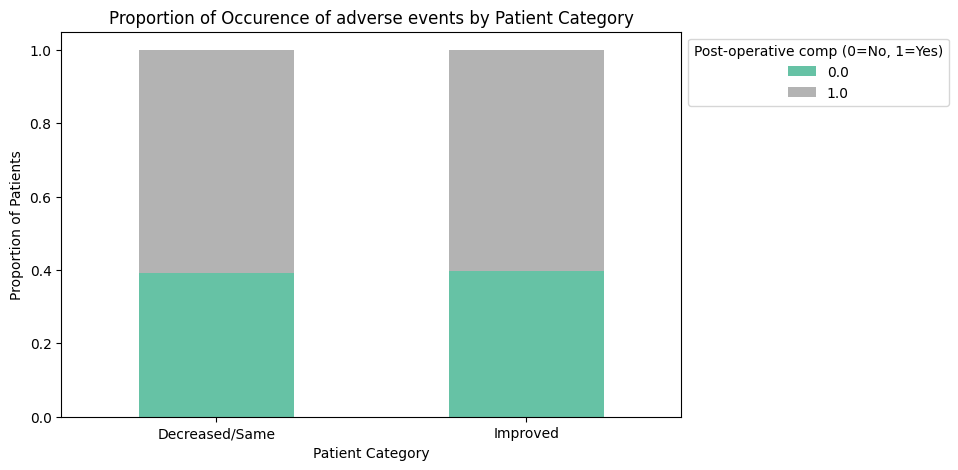

In [108]:
# Create proportion table
proportions = aligned_df.groupby("Trend Category")["postop_comp"].value_counts(normalize=True).unstack()
print(proportions)
# Plot bar chart
proportions.plot(kind="bar", stacked=True, colormap="Set2", figsize=(8, 5))
plt.xlabel("Patient Category")
plt.ylabel("Proportion of Patients")
plt.title("Proportion of Occurence of adverse events by Patient Category")
plt.legend(title="Post-operative comp (0=No, 1=Yes)",  bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

# statistically significantly associated with 2) hospital length of stay (los)

In [110]:
# Count the number of occurrences for each Trend Category
trend_category_counts = aligned_df["Trend Category"].value_counts()

# Calculate the average Change for each Trend Category
avg_change_by_category = aligned_df.groupby("Trend Category")["Change"].mean()

# Print results
print("Count of each Trend Category:")
print(trend_category_counts)

print("\nAverage Change for each Trend Category:")
print(avg_change_by_category)


Count of each Trend Category:
Trend Category
Improved          103
Decreased/Same     56
Name: count, dtype: int64

Average Change for each Trend Category:
Trend Category
Decreased/Same   -2.587798
Improved          4.642718
Name: Change, dtype: float64


In [111]:
aligned_df.groupby("Trend Category")[["Change"]].describe()

Change                                                   
                count      mean       std   min    25%    50%  75%   max
Trend Category                                                          
Decreased/Same   56.0 -2.587798  2.807971 -10.0 -4.125 -1.375  0.0   0.0
Improved        103.0  4.642718  3.206602   0.5  2.000  4.000  6.0  15.0

In [112]:
# Separate hospital length of stay (los) values by Trend Category
los_improved = aligned_df.loc[aligned_df["Trend Category"] == "Improved", "los"]
los_not_improved = aligned_df.loc[aligned_df["Trend Category"] == "Decreased/Same", "los"]

# Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(los_improved, los_not_improved, alternative="less")

print(f"Mann-Whitney U Test statistic: {u_stat}")
print(f"Mann-Whitney U Test p-value: {p_value}")

Mann-Whitney U Test statistic: 2315.5
Mann-Whitney U Test p-value: 0.018599398439203177


In [113]:
# Calculate mean LOS for each category
avg_los_improved = los_improved.mean()
avg_los_not_improved = los_not_improved.mean()

print(f"Average LOS for Improved: {avg_los_improved:.2f}")
print(f"Average LOS for Not Improved: {avg_los_not_improved:.2f}")

Average LOS for Improved: 13.11
Average LOS for Not Improved: 16.61


In [114]:
# Get comprehensive descriptive statistics
print("Improved Group Statistics:")
print(los_improved.describe())

print("\nNot Improved Group Statistics:")
print(los_not_improved.describe())


Improved Group Statistics:
count    103.000000
mean      13.106796
std       14.851495
min        1.000000
25%        6.000000
50%        7.000000
75%       12.500000
max       72.000000
Name: los, dtype: float64

Not Improved Group Statistics:
count    56.000000
mean     16.607143
std      17.296010
min       6.000000
25%       6.750000
50%       8.000000
75%      19.750000
max      86.000000
Name: los, dtype: float64


In [115]:
# Or calculate standard error separately since describe() doesn't include it
se_improved = los_improved.std() / np.sqrt(len(los_improved))
se_not_improved = los_not_improved.std() / np.sqrt(len(los_not_improved))

print(f"\nStandard Errors:")
print(f"Improved: {se_improved:.2f}")
print(f"Not Improved: {se_not_improved:.2f}")


Standard Errors:
Improved: 1.46
Not Improved: 2.31


In [116]:

# Loop through thresholds 1 to 10
for threshold in range(1, 11):
    print(f"After filtered data to remove LOS < {threshold}:")
    
    # Filter data
    filtered_data = aligned_df[aligned_df["los"] >= threshold]
    los_improved_filtered = filtered_data.loc[filtered_data["Trend Category"] == "Improved", "los"]
    los_not_improved_filtered = filtered_data.loc[filtered_data["Trend Category"] == "Decreased/Same", "los"]
    
    # Calculate statistics for improved group
    improved_mean = los_improved_filtered.mean()
    improved_std = los_improved_filtered.std()
    improved_se = improved_std / np.sqrt(len(los_improved_filtered))
    improved_n = len(los_improved_filtered)
    
    # Calculate statistics for not improved group
    not_improved_mean = los_not_improved_filtered.mean()
    not_improved_std = los_not_improved_filtered.std()
    not_improved_se = not_improved_std / np.sqrt(len(los_not_improved_filtered))
    not_improved_n = len(los_not_improved_filtered)
    
    # Mann-Whitney U test
    u_stat, p_value = stats.mannwhitneyu(los_improved_filtered, los_not_improved_filtered, alternative="less")
    
    # Print results
    print(f"improved LOS avg (n:{improved_n}): mean {improved_mean:.2f} std: {improved_std:.2f} se: {improved_se:.2f}")
    print(f"non improved LOS avg (n:{not_improved_n}): mean {not_improved_mean:.2f} std: {not_improved_std:.2f} se: {not_improved_se:.2f}")
    print(f"MW U test p val: {p_value:.4f}")
    print()
    print("+" * 40)
    print()

After filtered data to remove LOS < 1:
improved LOS avg (n:103): mean 13.11 std: 14.85 se: 1.46
non improved LOS avg (n:56): mean 16.61 std: 17.30 se: 2.31
MW U test p val: 0.0186

++++++++++++++++++++++++++++++++++++++++

After filtered data to remove LOS < 2:
improved LOS avg (n:102): mean 13.23 std: 14.88 se: 1.47
non improved LOS avg (n:56): mean 16.61 std: 17.30 se: 2.31
MW U test p val: 0.0229

++++++++++++++++++++++++++++++++++++++++

After filtered data to remove LOS < 3:
improved LOS avg (n:102): mean 13.23 std: 14.88 se: 1.47
non improved LOS avg (n:56): mean 16.61 std: 17.30 se: 2.31
MW U test p val: 0.0229

++++++++++++++++++++++++++++++++++++++++

After filtered data to remove LOS < 4:
improved LOS avg (n:102): mean 13.23 std: 14.88 se: 1.47
non improved LOS avg (n:56): mean 16.61 std: 17.30 se: 2.31
MW U test p val: 0.0229

++++++++++++++++++++++++++++++++++++++++

After filtered data to remove LOS < 5:
improved LOS avg (n:101): mean 13.32 std: 14.92 se: 1.48
non improved

# statistically significantly associated with 3) 30-day hospital readmission rate (readmission_30d)

In [120]:
for category, group in aligned_df.groupby("Trend Category"):
    n = len(group)
    n_read = group["readmission_30d"].sum()
    prop = group["readmission_30d"].mean()
    std = group["readmission_30d"].std()
    print(f"{category} (n:{n}): n_read {n_read:.0f}, proportion {prop:.2f}, std: {std:.2f}")

Decreased/Same (n:56): n_read 3, proportion 0.05, std: 0.23
Improved (n:103): n_read 8, proportion 0.08, std: 0.27


### Chi-square test

In [117]:
# Create a contingency table
contingency_table_30re = pd.crosstab(aligned_df["Trend Category"], aligned_df["readmission_30d"])
print(contingency_table_30re)

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table_30re)

print(f"Chi-Square Test p-value: {p_value}")


readmission_30d  0.0  1.0
Trend Category           
Decreased/Same    53    3
Improved          95    8
Chi-Square Test p-value: 0.8065832320732297


### Fisher's exact test

In [118]:
odds_ratio, p_value = stats.fisher_exact(contingency_table_30re)
print(f"Fisher's Exact Test p-value: {p_value}")

Fisher's Exact Test p-value: 0.7479970144390798


### Logistic test

In [119]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
aligned_df["Trend Category_binary"] = aligned_df["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})

# Logistic Regression Model
X = sm.add_constant(aligned_df["Trend Category_binary"])  # Predictor
y = aligned_df["readmission_30d"]  # Outcome (0/1)

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.250451
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:        readmission_30d   No. Observations:                  159
Model:                          Logit   Df Residuals:                      157
Method:                           MLE   Df Model:                            1
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                0.004248
Time:                        16:00:33   Log-Likelihood:                -39.822
converged:                       True   LL-Null:                       -39.992
Covariance Type:            nonrobust   LLR p-value:                    0.5600
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.8717      0.593     -4.839      0.000      -4.035      -1.

# statistically significantly associated with 4) age (age_diagnosis)

In [121]:
# Separate hospital age values by Trend Category
age_improved = aligned_df.loc[aligned_df["Trend Category"] == "Improved", "age_diagnosis"]
age_not_improved = aligned_df.loc[aligned_df["Trend Category"] == "Decreased/Same", "age_diagnosis"]

# Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(age_improved, age_not_improved, alternative="less")

print(f"Mann-Whitney U Test statistic: {u_stat}")
print(f"Mann-Whitney U Test p-value: {p_value}")

Mann-Whitney U Test statistic: 2738.0
Mann-Whitney U Test p-value: 0.2999085057936902


In [122]:
# Calculate mean age for each category
avg_age_improved = age_improved.mean()
avg_age_not_improved = age_not_improved.mean()

print(f"Average age for Improved: {avg_age_improved:.2f}")
print(f"Average age for Not Improved: {avg_age_not_improved:.2f}")

Average age for Improved: 64.52
Average age for Not Improved: 65.78


# statistically significantly associated with 5) sex (gender)

### Chi-square test

In [124]:
# Create a contingency table
contingency_table_gender = pd.crosstab(aligned_df["Trend Category"], aligned_df["gender"])
print(contingency_table_gender)

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table_gender)

print(f"Chi-Square Test p-value: {p_value}")


gender          1.0  2.0
Trend Category          
Decreased/Same   47    9
Improved         81   22
Chi-Square Test p-value: 0.5522740312934186


### Fisher's exact test

In [125]:
odds_ratio, p_value = stats.fisher_exact(contingency_table_gender)
print(f"Fisher's Exact Test p-value: {p_value}")

Fisher's Exact Test p-value: 0.5308723733917453


### Logistic test

In [126]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
aligned_df["Trend Category_binary"] = aligned_df["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})

# Convert gender to binary (1 = Male, 0 = Female)
aligned_df["gender_binary"] = aligned_df["gender"].replace({2: 0})

# Logistic Regression Model
X = sm.add_constant(aligned_df["Trend Category_binary"])  # Predictor
y = aligned_df["gender_binary"]  # Outcome (0/1)

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.491267
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          gender_binary   No. Observations:                  159
Model:                          Logit   Df Residuals:                      157
Method:                           MLE   Df Model:                            1
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                0.004217
Time:                        16:14:27   Log-Likelihood:                -78.112
converged:                       True   LL-Null:                       -78.442
Covariance Type:            nonrobust   LLR p-value:                    0.4160
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.6529      0.364      4.543      0.000       0.940       2.

# statistically significantly associated with 6) clinical staging (overall_primary_tumour)

In [127]:
# Separate tumor stages by Trend Category
tumor_improved = aligned_df.loc[aligned_df["Trend Category"] == "Improved", "overall_primary_tumour"]
tumor_not_improved = aligned_df.loc[aligned_df["Trend Category"] == "Decreased/Same", "overall_primary_tumour"]

# Perform Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(tumor_improved, tumor_not_improved, alternative="greater")

# Print test results
print(f"Mann-Whitney U Test statistic: {u_stat}")
print(f"Mann-Whitney U Test p-value: {p_value}")

Mann-Whitney U Test statistic: 2822.5
Mann-Whitney U Test p-value: 0.6338322897846226


In [128]:
# Calculate mean tumor stage for each category
avg_tumor_improved = tumor_improved.mean()
avg_tumor_not_improved = tumor_not_improved.mean()

print(f"Average tumor stage for Improved: {avg_tumor_improved:.2f}")
print(f"Average tumor stage for Not Improved: {avg_tumor_not_improved:.2f}")

Average tumor stage for Improved: 2.86
Average tumor stage for Not Improved: 2.89


# statistically significantly associated with 7) clinical staging (overall_regional_ln)

In [129]:
# Separate ln stages by Trend Category
ln_improved = aligned_df.loc[aligned_df["Trend Category"] == "Improved", "overall_regional_ln"]
ln_not_improved = aligned_df.loc[aligned_df["Trend Category"] == "Decreased/Same", "overall_regional_ln"]

# Perform Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(ln_improved, ln_not_improved, alternative="greater")

# Print test results
print(f"Mann-Whitney U Test statistic: {u_stat}")
print(f"Mann-Whitney U Test p-value: {p_value}")

Mann-Whitney U Test statistic: 2959.0
Mann-Whitney U Test p-value: 0.3842364829544497


In [130]:
# Calculate mean ln stage for each category
avg_ln_improved = ln_improved.mean()
avg_ln_not_improved = ln_not_improved.mean()

print(f"Average ln stage for Improved: {avg_ln_improved:.2f}")
print(f"Average ln stage for Not Improved: {avg_ln_not_improved:.2f}")

Average ln stage for Improved: 0.91
Average ln stage for Not Improved: 0.79


# statistically significantly associated with 8) clinical staging (overall_distant_metastasis)

### Chi-square test

In [131]:
# Create a contingency table
contingency_table_M = pd.crosstab(aligned_df["Trend Category"], aligned_df["overall_distant_metastasis"])
print(contingency_table_M)

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table_M)

print(f"Chi-Square Test p-value: {p_value}")


overall_distant_metastasis  0.0  1.0
Trend Category                      
Decreased/Same               52    4
Improved                     94    9
Chi-Square Test p-value: 0.9620052428698602


### Fisher's exact test

In [132]:
odds_ratio, p_value = stats.fisher_exact(contingency_table_M)
print(f"Fisher's Exact Test p-value: {p_value}")

Fisher's Exact Test p-value: 1.0


### Logistic test

In [133]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
aligned_df["Trend Category_binary"] = aligned_df["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})

# Logistic Regression Model
X = sm.add_constant(aligned_df["Trend Category_binary"])  # Predictor
y = aligned_df["overall_distant_metastasis"]  # Outcome (0/1)

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.282655
         Iterations 7
                               Logit Regression Results                               
Dep. Variable:     overall_distant_metastasis   No. Observations:                  159
Model:                                  Logit   Df Residuals:                      157
Method:                                   MLE   Df Model:                            1
Date:                        Thu, 02 Apr 2026   Pseudo R-squ.:                0.001392
Time:                                16:27:12   Log-Likelihood:                -44.942
converged:                               True   LL-Null:                       -45.005
Covariance Type:                    nonrobust   LLR p-value:                    0.7233
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 

# statistically significantly associated with 9) Neoadjuvant treatment (six neotx)

In [134]:
# List of binary treatment columns
treatment_columns = ["neotx___notx", "neotx___chemo", "neotx___rads", 
                    "neotx___chemorads", "neotx___immuno", "neotx___other"]

for col in treatment_columns:
    print(f"\n### Analyzing: {col} ###\n")
    
    merged_df = aligned_df.copy()  
    # Create a contingency table
    contingency_table = pd.crosstab(merged_df["Trend Category"], merged_df[col])
    print(contingency_table)
    
    # Chi-square test
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"Chi-Square Test p-value: {p_value}")

    # Fisher's Exact Test (only if 2x2 table)
    if contingency_table.shape == (2, 2):
        odds_ratio, p_value_fisher = stats.fisher_exact(contingency_table)
        print(f"Fisher's Exact Test p-value: {p_value_fisher}")

    # Convert Trend Category to binary (1 = Improved, 0 = Decreased/Same)
    merged_df["Trend Category_binary"] = merged_df["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})

    # Logistic Regression Model
    X = sm.add_constant(merged_df["Trend Category_binary"])
    y = merged_df[col]  # Treatment variable (0/1)
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        print(result.summary())
    except Exception as e:
        print(f"Logistic regression failed: {e}")



### Analyzing: neotx___notx ###

neotx___notx    0.0  1.0
Trend Category          
Decreased/Same   56    0
Improved         99    4
Chi-Square Test p-value: 0.33528974283311325
Fisher's Exact Test p-value: 0.298152073247569
                           Logit Regression Results                           
Dep. Variable:           neotx___notx   No. Observations:                  159
Model:                          Logit   Df Residuals:                      157
Method:                           MLE   Df Model:                            1
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                 0.09447
Time:                        16:46:17   Log-Likelihood:                -16.915
converged:                      False   LL-Null:                       -18.680
Covariance Type:            nonrobust   LLR p-value:                   0.06029
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# statistically significantly associated with 10) surgery type (procedure123456)

### Chi-square test

In [135]:
# Create a contingency table
contingency_table_procedure = pd.crosstab(aligned_df["Trend Category"], aligned_df["procedure123456"])
print(contingency_table_procedure)

# Perform Chi-Square test
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table_procedure)

print(f"Chi-Square statistic: {chi2_stat}")
print(f"P-value: {p_val}")


procedure123456  1.0  2.0  3.0  4.0  5.0  6.0  8.0
Trend Category                                    
Decreased/Same    35    8    1    6    6    0    0
Improved          72   11    3   12    2    1    2
Chi-Square statistic: 8.081104711749886
P-value: 0.23222140140078262


### Logistic test

In [136]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
aligned_df["Trend Category_binary"] = aligned_df["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})


# Convert procedure to categorical dummy variables
procedure_dummies = pd.get_dummies(aligned_df["procedure123456"], prefix="procedure", dtype=int)

# Add a constant term for logistic regression
X = sm.add_constant(procedure_dummies)
y = aligned_df["Trend Category_binary"]

# Fit logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

print(result.summary())


         Current function value: 0.621212
         Iterations: 35
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  159
Model:                             Logit   Df Residuals:                      152
Method:                              MLE   Df Model:                            6
Date:                   Thu, 02 Apr 2026   Pseudo R-squ.:                 0.04252
Time:                           16:50:10   Log-Likelihood:                -98.773
converged:                         False   LL-Null:                       -103.16
Covariance Type:               nonrobust   LLR p-value:                    0.1868
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.1799        nan        nan        nan         nan         nan
procedure_1.0    -5.4586        

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# statistically significantly associated with 11) Multivariate 

In [143]:
aligned_df

,id,Baseline,Preoperative,Change,Trend Category,age_diagnosis,gender,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,...,neotx___chemo,neotx___rads,neotx___chemorads,neotx___immuno,neotx___other,postop_comp,readmission_30d,los,procedure123456,Trend_Binary
1,55,8.0,14.0,6.0,Improved,64.617343,1.0,3.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1
3,78,17.0,20.0,3.0,Improved,69.794725,1.0,4.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,4.0,1
4,125,21.0,16.0,-5.0,Decreased/Same,64.110830,1.0,3.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,1.0,0
7,127,5.0,12.0,7.0,Improved,63.661700,1.0,2.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,8.0,2.0,1
9,128,22.0,23.0,1.0,Improved,62.698070,1.0,3.0,3.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,51.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,1577,14.0,6.0,-8.0,Decreased/Same,78.460201,1.0,4.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,4.0,0
317,1597,12.0,17.0,5.0,Improved,69.499031,2.0,3.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1
318,1622,17.0,16.0,-1.0,Decreased/Same,64.491285,1.0,3.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,1.0,0
321,1643,17.0,19.0,2.0,Improved,60.214789,1.0,3.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,1.0,1


In [142]:
aligned_df.columns.tolist()

['id',
 'Baseline',
 'Preoperative',
 'Change',
 'Trend Category',
 'age_diagnosis',
 'gender',
 'overall_primary_tumour',
 'overall_regional_ln',
 'overall_distant_metastasis',
 'neotx___notx',
 'neotx___chemo',
 'neotx___rads',
 'neotx___chemorads',
 'neotx___immuno',
 'neotx___other',
 'postop_comp',
 'readmission_30d',
 'los',
 'procedure123456',
 'Trend_Binary']

#### when y = postop_comp

In [145]:

from statsmodels.tools.sm_exceptions import PerfectSeparationError

# Get all column names
all_columns = aligned_df.columns.tolist()

# Remove the dependent variable and excluded variables
exclude_variables = ['postop_comp', 'id', 'Baseline', 'Preoperative', 'Change', 'Trend Category', 'readmission_30d', 'los', 'neotx___other']
for var in exclude_variables:
    if var in all_columns:
        all_columns.remove(var)

# Create correlation matrix to identify highly correlated variables
correlation_matrix = aligned_df[all_columns].corr().abs()

# Identify pairs of highly correlated features (above 0.8)
high_corr_vars = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if correlation_matrix.iloc[i, j] > 0.8:
            high_corr_vars.add(correlation_matrix.columns[i])

print(f"Highly correlated variables: {high_corr_vars}")

# Remove highly correlated variables
for var in high_corr_vars:
    if var in all_columns:
        all_columns.remove(var)

# Make sure our main variable of interest is included
if 'Trend_Binary' not in all_columns and 'Trend_Binary' in aligned_df.columns:
    all_columns.append('Trend_Binary')

# Prepare the independent variables (X) and dependent variable (y)
X = aligned_df[all_columns]
y = aligned_df['postop_comp']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

try:
    logit_model = sm.Logit(y, X)
    result = logit_model.fit()
    print(result.summary())

    # OR and 95% CI
    odds_ratios = pd.DataFrame({
        'OR': np.exp(result.params),
        'CI Lower': np.exp(result.conf_int()[0]),
        'CI Upper': np.exp(result.conf_int()[1]),
        'p-value': result.pvalues
    })
    print("\nOdds Ratios with 95% CI:")
    print(odds_ratios)

except PerfectSeparationError:
    print("Perfect separation detected.")
    # In this case, you might need to use alternative methods
    # Like exact logistic regression from statsmodels.miscmodels.logit
    # Or reduce the number of variables even further

Highly correlated variables: set()
Optimization terminated successfully.
         Current function value: 0.621807
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            postop_comp   No. Observations:                  159
Model:                          Logit   Df Residuals:                      146
Method:                           MLE   Df Model:                           12
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                 0.07394
Time:                        17:24:20   Log-Likelihood:                -98.867
converged:                       True   LL-Null:                       -106.76
Covariance Type:            nonrobust   LLR p-value:                    0.2012
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.0601    

#### when y = Readmission_30d

In [148]:

# Get all column names
all_columns = aligned_df.columns.tolist()

# Remove the dependent variable and excluded variables
exclude_variables = ['readmission_30d', 'id', 'Baseline', 'Preoperative', 'Change', 'Trend Category', 'postop_comp', 'los', 'neotx___notx', 'neotx___rads', 'neotx___other']
for var in exclude_variables:
    if var in all_columns:
        all_columns.remove(var)

# Create correlation matrix to identify highly correlated variables
correlation_matrix = aligned_df[all_columns].corr().abs()

# Identify pairs of highly correlated features (above 0.8)
high_corr_vars = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if correlation_matrix.iloc[i, j] > 0.8:
            high_corr_vars.add(correlation_matrix.columns[i])

print(f"Highly correlated variables: {high_corr_vars}")

# Remove highly correlated variables
for var in high_corr_vars:
    if var in all_columns:
        all_columns.remove(var)

# Make sure our main variable of interest is included
if 'Trend_Binary' not in all_columns and 'Trend_Binary' in aligned_df.columns:
    all_columns.append('Trend_Binary')

# Prepare the independent variables (X) and dependent variable (y)
X = aligned_df[all_columns]
y = aligned_df['readmission_30d']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

try:
    logit_model = sm.Logit(y, X)
    result = logit_model.fit()
    print(result.summary())

    # OR and 95% CI
    odds_ratios = pd.DataFrame({
        'OR': np.exp(result.params),
        'CI Lower': np.exp(result.conf_int()[0]),
        'CI Upper': np.exp(result.conf_int()[1]),
        'p-value': result.pvalues
    })
    print("\nOdds Ratios with 95% CI:")
    print(odds_ratios)

except PerfectSeparationError:
    print("Perfect separation detected.")
    # In this case, you might need to use alternative methods
    # Like exact logistic regression from statsmodels.miscmodels.logit
    # Or reduce the number of variables even further

Highly correlated variables: set()
Optimization terminated successfully.
         Current function value: 0.228966
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        readmission_30d   No. Observations:                  159
Model:                          Logit   Df Residuals:                      148
Method:                           MLE   Df Model:                           10
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                 0.08967
Time:                        17:31:31   Log-Likelihood:                -36.406
converged:                       True   LL-Null:                       -39.992
Covariance Type:            nonrobust   LLR p-value:                    0.7091
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -7.0520    

#### when y = los

In [149]:

from statsmodels.tools.sm_exceptions import PerfectSeparationError

# Get all column names
all_columns = aligned_df.columns.tolist()

# Remove the dependent variable and excluded variables
exclude_variables = ['los', 'id', 'Baseline', 'Preoperative', 'Change', 'Trend Category', 'postop_comp', 'readmission_30d', 'neotx___other']
for var in exclude_variables:
    if var in all_columns:
        all_columns.remove(var)

# Create correlation matrix to identify highly correlated variables
correlation_matrix = aligned_df[all_columns].corr().abs()

# Identify pairs of highly correlated features (above 0.8)
high_corr_vars = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if correlation_matrix.iloc[i, j] > 0.8:
            high_corr_vars.add(correlation_matrix.columns[i])

print(f"Highly correlated variables: {high_corr_vars}")

# Remove highly correlated variables
for var in high_corr_vars:
    if var in all_columns:
        all_columns.remove(var)

# Make sure our main variable of interest is included
if 'Trend_Binary' not in all_columns and 'Trend_Binary' in aligned_df.columns:
    all_columns.append('Trend_Binary')

# Prepare the independent variables (X) and dependent variable (y)
X = aligned_df[all_columns]
y = aligned_df['los']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

ols_model = sm.OLS(y, X)
result = ols_model.fit()
print(result.summary())

# β and 95% CI
beta_ci = pd.DataFrame({
    'β': result.params,
    'CI Lower': result.conf_int()[0],
    'CI Upper': result.conf_int()[1],
    'p-value': result.pvalues
})
print("\nβ with 95% CI:")
print(beta_ci)

Highly correlated variables: set()
                            OLS Regression Results                            
Dep. Variable:                    los   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     3.133
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           0.000548
Time:                        17:37:46   Log-Likelihood:                -645.64
No. Observations:                 159   AIC:                             1317.
Df Residuals:                     146   BIC:                             1357.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------